In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import prince
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from src.utils.config import (
    EDA_OUTPUT_PARAMS_PATH,
    FE_OUTPUT_PARAMS_PATH,
    TRAINING_OUTPUT_PLOTS_PATH,
    FE_OUTPUT_SCALER_PATH,
)
from src.data.processed_data import get_feature_engineered_data
from src.data.processed_data import get_validated_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_scatterplot
from kmodes.kprototypes import KPrototypes

In [3]:
featured_data = get_feature_engineered_data()
validated_data = get_validated_data()

with open(EDA_OUTPUT_PARAMS_PATH, "r", encoding="utf-8") as file:
    eda_output = json.load(file)
with open(FE_OUTPUT_PARAMS_PATH, 'r', encoding="utf-8") as file:
    fe_output = json.load(file)
validated_data

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues
...,...,...,...,...,...,...,...,...,...,...
63990,3097010,X Simulator Drone,2024,2024-07-31,Casual;Indie;Simulation,Single-player;Family Sharing,14.99,0,Inonia Games,Inonia Games
63991,3304930,Retro Dungeon Slayer,2025,2025-03-03,Action;Indie;Early Access,Single-player;Family Sharing,4.99,0,Hard Shark Games,Hard Shark Games
63992,1461580,Molecule Builder,2021,2021-02-04,Simulation;Education,Single-player;Tracked Controller Support;VR On...,14.99,0,Xennial Digital,Xennial Digital
63993,1379120,MechNest,2024,2024-04-13,Action;Indie,Single-player;Partial Controller Support;Famil...,15.99,0,PoisonGames,PoisonGames


# Data PCA Visualizations

In [4]:
# Use pca for visualization
pca = PCA(n_components=10)
trained_pca = pca.fit_transform(featured_data)
pc_df = pd.DataFrame(trained_pca[:, :3], columns=["PC1", "PC2", "PC3"])
discrete_columns = pd.DataFrame(validated_data["price"] == 0)
discrete_columns["recommendations"] = validated_data["recommendations"] > 100
genres = featured_data[fe_output['genres']].reset_index(drop=True)
categories = featured_data[fe_output['categories']].reset_index(drop=True)
genres


,Indie,Casual,Adventure,Action,Simulation,Strategy,RPG,Free To Play,Early Access,Sports,Racing
0,1.351654,0.000000,1.903404,1.934981,0.00000,2.618464,2.647094,0.0,0.000000,0.0,0.0
1,1.351654,1.752587,0.000000,0.000000,2.51001,2.618464,0.000000,0.0,0.000000,0.0,0.0
2,1.351654,0.000000,1.903404,0.000000,0.00000,2.618464,0.000000,0.0,0.000000,0.0,0.0
3,1.351654,0.000000,1.903404,1.934981,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0
4,1.351654,1.752587,1.903404,1.934981,0.00000,0.000000,2.647094,0.0,3.250004,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
63990,1.351654,1.752587,0.000000,0.000000,2.51001,0.000000,0.000000,0.0,0.000000,0.0,0.0
63991,1.351654,0.000000,0.000000,1.934981,0.00000,0.000000,0.000000,0.0,3.250004,0.0,0.0
63992,0.000000,0.000000,0.000000,0.000000,2.51001,0.000000,0.000000,0.0,0.000000,0.0,0.0
63993,1.351654,0.000000,0.000000,1.934981,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0


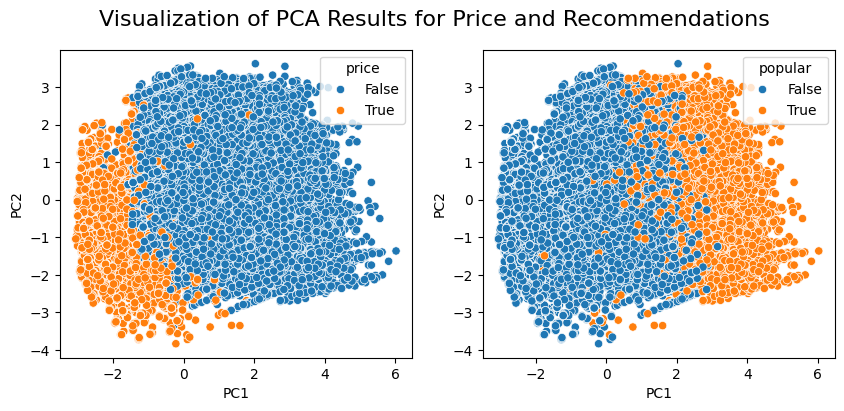

'multiple_scatterplot(\n    data=pc_df,\n    title="Visualization of PCA Results per genre",\n    x_col="PC1",\n    y_col="PC2",\n    n=3,\n    m=4,\n    hue_values=genres,\n    xsize=16,\n    ysize=8,\n)\nmultiple_scatterplot(\n    data=pc_df,\n    title="Visualization of PCA Results per category",\n    x_col="PC1",\n    y_col="PC2",\n    n=3,\n    m=2,\n    hue_values=categories,\n    xsize=14,\n    ysize=7,\n)'

In [ ]:
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results for Price and Recommendations",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=discrete_columns,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results per genre",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results per category",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

# Test variance to define optimal Centroids

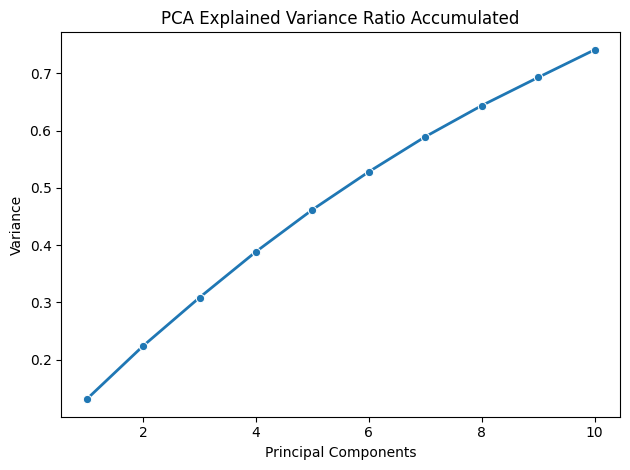

Total variance explained by PC1+PC2+PC3: 0.30852282
Variance explained by each Principal Component: [0.13096902 0.09305187 0.08450194 0.08002494 0.07327636 0.06621873
 0.06118968 0.05434614 0.04913573 0.04821097]
Accumulated Variance: [0.13096902 0.2240209  0.30852282 0.38854775 0.46182412 0.52804285
 0.5892325  0.64357865 0.6927144  0.7409254 ]


In [14]:
# Visualice accumulated variance ratio of principal components
make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=pca.explained_variance_ratio_.cumsum(),
    title='PCA Explained Variance Ratio Accumulated',
    xlabel="Principal Components",
    ylabel="Variance",
)
plt.show()

print(
    "Total variance explained by PC1+PC2+PC3:", pca.explained_variance_ratio_[:3].sum()
)
print("Variance explained by each Principal Component:", pca.explained_variance_ratio_)
print("Accumulated Variance:", pca.explained_variance_ratio_.cumsum())

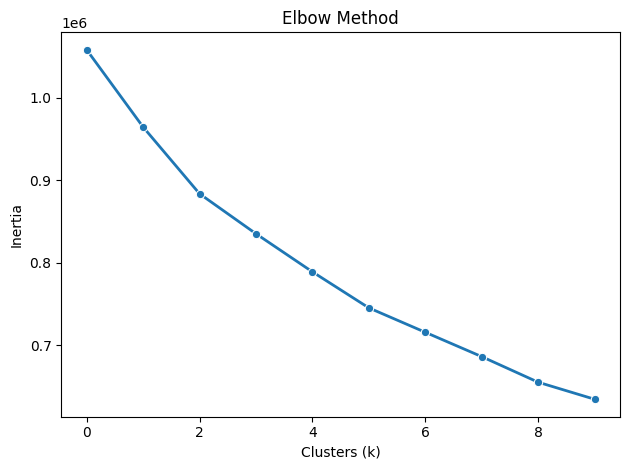

In [5]:
# Visualice elbow method on inertias
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(featured_data)
    inertias.append(km.inertia_)

make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title='Elbow Method',
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=k_range,
)
plt.show()

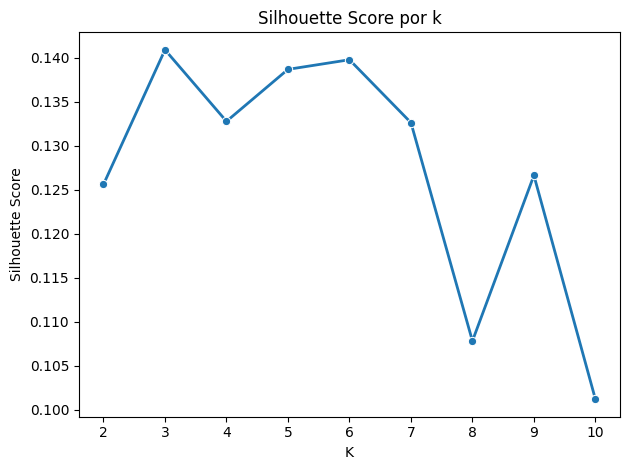

In [ ]:
# Visualice Silhouette Score
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(featured_data)
    sil_scores.append(silhouette_score(featured_data, labels))

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores,
    title='Silhouette Score por k',
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

In [6]:
# See what features influence more on each principal component
loadings = pd.DataFrame(
    pca.components_.T[:, :3], columns=["PC1", "PC2", "PC3"], index=featured_data.columns
)
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))
print(loadings["PC3"].abs().sort_values(ascending=False).head(5))

price                      0.502221
Steam Cloud                0.440856
recommendations            0.405347
Free To Play               0.397360
Full controller support    0.331779
Name: PC1, dtype: float32
Simulation                 0.507544
Action                     0.439920
Full controller support    0.409995
Strategy                   0.390094
Free To Play               0.245732
Name: PC2, dtype: float32
Multi-player    0.658645
Early Access    0.427242
Strategy        0.300723
Sports          0.205108
Action          0.204560
Name: PC3, dtype: float32


# First unsupervised model Training
### KMeans with weighed genres and categories.

In [7]:
# Train a KMEANS model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(featured_data)
pc_df["labels"] = kmeans_labels
fig = px.scatter_3d(
    pc_df, x="PC1", y="PC2", z="PC3", color="labels", title="PCA 3D Visualization"
)
centroids_cords = pc_df.groupby("labels")[["PC1", "PC2", "PC3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords["PC1"],
        y=centroids_cords["PC2"],
        z=centroids_cords["PC3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords["labels"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()
fig.write_html(TRAINING_OUTPUT_PLOTS_PATH)

In [ ]:
# Analyce kmeans labels output
scaler = joblib.load(FE_OUTPUT_SCALER_PATH)
centroids = kmeans.cluster_centers_

df_centroids = pd.DataFrame(
    centroids,
    columns=featured_data.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)]
)

# See mean value columns for cluster
for i in range(kmeans.n_clusters):
    top_genres = df_centroids.loc[f"Cluster {i}", featured_data.columns].sort_values(ascending=False)
    print(f"\n--- Cluster {i} ---")
    price_recommendations = [[df_centroids.loc[f'Cluster {i}', 'price'], df_centroids.loc[f'Cluster {i}', 'recommendations']]]
    print(f"Centroid mean price: {df_centroids.loc[f'Cluster {i}', 'price']}")
    print(f"Centroid mean recommendations: {df_centroids.loc[f'Cluster {i}', 'recommendations']}")
    print(f"Transformed price and recommendations: {scaler.inverse_transform(price_recommendations)}")
    print("Top genres/categories:")
    print(top_genres)

3

--- Cluster 0 ---
Centroid mean price: -0.13699322938919067
Centroid mean recommendations: -0.14036796987056732
Transformed price and recommendations: [[1.44393592 0.47707307]]
Top genres/categories:
Multi-player                  1.979262
Early Access                  1.554329
Action                        1.045579
Indie                         0.915168
Single-player                 0.831040
Casual                        0.749076
Strategy                      0.686073
Free To Play                  0.655199
Adventure                     0.610312
Simulation                    0.556152
Steam Achievements            0.534189
RPG                           0.515310
Partial Controller Support    0.457435
Full controller support       0.436476
Sports                        0.337234
Racing                        0.282371
Steam Cloud                   0.209111
price                        -0.136993
recommendations              -0.140368
Name: Cluster 0, dtype: float32

--- Cluster 1 ---
Centr

# Second unsupervised model Training
### Kprototypes with genres and categories being booleans.

In [24]:
# Prepare data
numeric_cols = discrete_columns.columns
categorical_cols = np.concat([genres.columns, categories.columns])
testdata = featured_data.copy()

for c in categorical_cols:
    testdata[c] = testdata[c].astype('category')
for c in numeric_cols:
    testdata[c] = testdata[c].astype(float)

cat_indices = [testdata.columns.get_loc(c) for c in categorical_cols]
X_matrix = testdata.to_numpy()

k=2 -> cost=178295.22
k=3 -> cost=140487.57
k=4 -> cost=129293.43
k=5 -> cost=122665.66
k=6 -> cost=116516.01
k=7 -> cost=113031.29
k=8 -> cost=109336.38
k=9 -> cost=106484.73
k=10 -> cost=103499.22


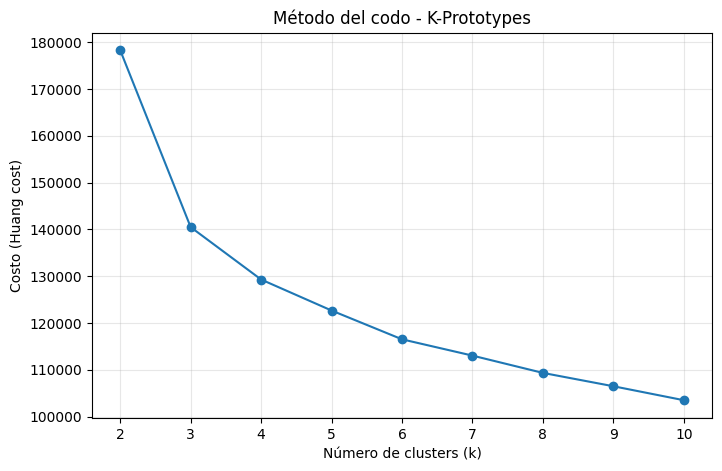

In [ ]:
costs = []
K_range = range(2, 11)

for k in K_range:
    kproto_k = KPrototypes(
        n_clusters=k,
        init='Huang',
        n_init=10,        # bajo aquí para que el loop de búsqueda sea rápido
        random_state=42,
        verbose=0
    )
    kproto_k.fit_predict(X_matrix, categorical=cat_indices)
    costs.append(kproto_k.cost_)
    print(f"k={k} -> cost={kproto_k.cost_:.2f}")

plt.figure(figsize=(8,5))
plt.plot(list(K_range), costs, marker='o')
plt.xlabel('Clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method - K-Prototypes')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Detect the optimal K value
from kneed import KneeLocator
kl = KneeLocator(list(K_range), costs, curve='convex', direction='decreasing')
k_optimo = kl.elbow
print("Suggested K value: ", k_optimo)

k óptimo sugerido: 4


In [ ]:
# Optimal training
kproto_final = KPrototypes(
    n_clusters=4, 
    init='Huang',
    n_init=20, # Final model, hight n_init 
    gamma=None,
    random_state=42,
    verbose=0
)

clusters = kproto_final.fit_predict(X_matrix, categorical=cat_indices)
testdata['cluster_kproto'] = clusters

print("Model final cost:", kproto_final.cost_)
print(testdata['cluster_kproto'].value_counts())

Costo final del modelo: 129293.42927059808
cluster_kproto
1    22126
2    21681
3    12271
0     7917
Name: count, dtype: int64


[11.74763146  9.03860415  8.16879937]


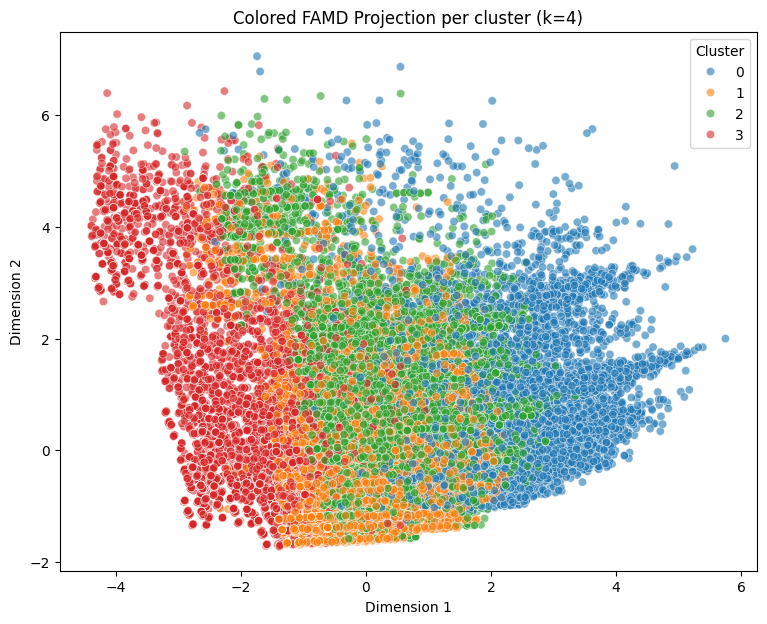

In [ ]:
# FAMD visualization
X_famd = featured_data.copy()
for c in categorical_cols:
    X_famd[c] = X_famd[c].astype('category')
for c in numeric_cols:
    X_famd[c] = X_famd[c].astype(float)

famd = prince.FAMD(n_components=3, n_iter=3, random_state=42)
famd = famd.fit(X_famd)

coords = famd.row_coordinates(X_famd)
coords.columns = ['Dim1', 'Dim2', 'Dim3']
coords['cluster'] = testdata['cluster_kproto'].values

print(famd.percentage_of_variance_)  # varianza explicada por cada dimensión

plt.figure(figsize=(9,7))
sns.scatterplot(data=coords, x='Dim1', y='Dim2', hue='cluster', palette='tab10', alpha=0.6)
plt.title(f'Colored FAMD Projection per cluster (k={4})')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Cluster')
plt.show()

In [23]:
fig = px.scatter_3d(
    coords, x="Dim1", y="Dim2", z="Dim3", color="cluster", title="FAMD 3D Visualization"
)
centroids_cords_FAMD = coords.groupby("cluster")[["Dim1", "Dim2", "Dim3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords_FAMD["Dim1"],
        y=centroids_cords_FAMD["Dim2"],
        z=centroids_cords_FAMD["Dim3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords_FAMD["cluster"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()